# Prior Power Spectrum Mismatch Study

How sensitive is the Wiener filter mapmaking to errors in the assumed
prior power spectrum? We scale the true prior by a factor $\alpha$ and
measure how the recovered map degrades.

Uses the lake beam configuration at 109 MHz (best frequency).

## 1. Setup and Verification

Load the saved config, re-run the SVD for one frequency to get
the full products ($U$, $\Sigma$, $V^H$, projected data $c$),
and verify that $\alpha = 1$ reproduces the saved result.

In [1]:
from pathlib import Path

import healpy as hp
import jax
import matplotlib.pyplot as plt
import numpy as np
import yaml

jax.config.update("jax_enable_x64", True)

import mistsim.pipeline as mspipe
import mistsim.plotting as msplt

%matplotlib widget

In [2]:
npz_path = Path("results/all-nominal-multifreq-lake.npz")
d = np.load(npz_path, allow_pickle=True)

config = yaml.safe_load(str(d["config_yaml"]))
lmax = int(d["lmax"])
sim_freqs = d["sim_freqs"]

# Best frequency: 109 MHz, index 69
freq_idx = 69
freq_mhz = sim_freqs[freq_idx]
print(f"Target frequency: {freq_mhz:.0f} MHz (index {freq_idx})")
print(f"lmax = {lmax}")

Target frequency: 109 MHz (index 69)
lmax = 90


In [3]:
# Re-run SVD for one frequency (takes a few minutes)
products = mspipe.prior_mismatch_products(config, freq_idx)

Sigma = products["Sigma"]
Vh = products["Vh"]
c = products["c"]
Sdiag = products["Sdiag"]
x_true_hp = products["x_true_hp"]
nvec = products["nvec"]

print(f"SVD rank k = {len(Sigma)}, nvec = {nvec}")
print(f"Sigma range: {Sigma[0]:.2f} -- {Sigma[-1]:.2e}")

SVD rank k = 2000, nvec = 1465
Sigma range: 994155.45 -- 9.66e-11


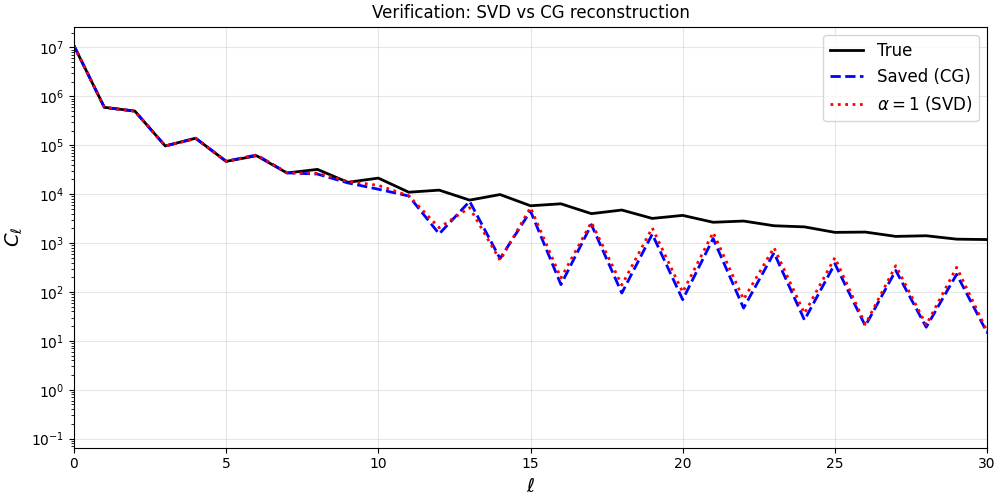

RMS difference (l<=10): 3.18e+01
Fractional: 2.53e-02


In [4]:
# Verify: alpha=1 should match saved x_rec
res_a1 = mspipe.wiener_filter_alpha(
    Sigma, Vh, c, Sdiag, alpha=1.0, nvec=nvec, lmax=lmax,
)
x_rec_a1 = res_a1["x_rec_hp"]
x_rec_saved = d["x_rec"][freq_idx]

# Compare in Cl space
cl_a1 = hp.alm2cl(x_rec_a1)
cl_saved = hp.alm2cl(x_rec_saved)
cl_true = hp.alm2cl(x_true_hp)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ell = np.arange(len(cl_true))
ax.semilogy(ell, cl_true, "k-", lw=2, label="True")
ax.semilogy(ell, cl_saved, "b--", lw=2, label="Saved (CG)")
ax.semilogy(ell, cl_a1, "r:", lw=2, label=r"$\alpha=1$ (SVD)")
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$C_\ell$", fontsize=14)
ax.set_title("Verification: SVD vs CG reconstruction")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(0, 30)
plt.show()

# Quantify discrepancy
nside = 128
fl = np.zeros(lmax + 1); fl[:11] = 1.0
map_a1 = hp.alm2map(hp.almxfl(x_rec_a1, fl), nside)
map_saved = hp.alm2map(hp.almxfl(x_rec_saved, fl), nside)
rms_diff = np.sqrt(np.mean((map_a1 - map_saved)**2))
rms_signal = np.sqrt(np.mean(map_saved**2))
print(f"RMS difference (l<=10): {rms_diff:.2e}")
print(f"Fractional: {rms_diff / rms_signal:.2e}")

## 2. Sweep Prior Scaling Factor $\alpha$

Apply Wiener filter with prior $\alpha \cdot C_\ell^{\rm true}$
for a range of $\alpha$ values.

In [5]:
alphas = [0.01, 0.1, 0.5, 0.9, 1.0, 1.1, 2.0, 10.0, 100.0]

results = {}
for alpha in alphas:
    res = mspipe.wiener_filter_alpha(
        Sigma, Vh, c, Sdiag, alpha=alpha,
        nvec=nvec, lmax=lmax,
    )
    results[alpha] = res
    print(f"alpha={alpha:>6.2f} done")

print(f"\n{len(alphas)} alpha values computed")

alpha=  0.01 done
alpha=  0.10 done
alpha=  0.50 done
alpha=  0.90 done
alpha=  1.00 done
alpha=  1.10 done
alpha=  2.00 done
alpha= 10.00 done
alpha=100.00 done

9 alpha values computed


## 3. Filter Factors

Wiener filter factors $D_i^\alpha = \sqrt{\alpha}\,\sigma_i / (1 + \alpha\,\sigma_i^2)$
for different prior scaling. Shows how the prior redistributes
information across SVD modes.

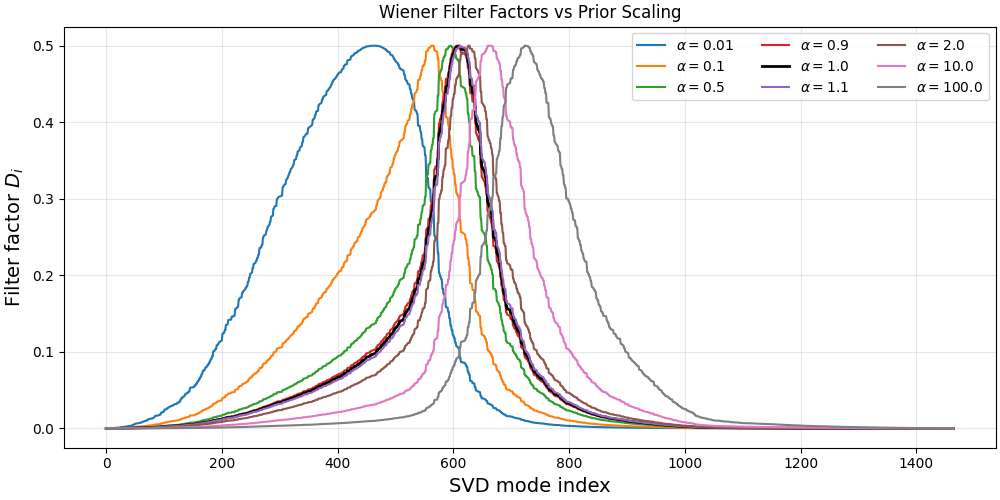

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

for alpha in alphas:
    D = results[alpha]["D_alpha"]
    if np.isclose(alpha, 1):
        ax.plot(D, label="$\\alpha=1.0$", lw=2, c="k")
        continue
    ax.plot(D, label=rf"$\alpha={alpha}$")
ax.set_xlabel("SVD mode index", fontsize=14)
ax.set_ylabel("Filter factor $D_i$", fontsize=14)
ax.set_title("Wiener Filter Factors vs Prior Scaling")
ax.legend(fontsize=10, ncol=3)
ax.grid(alpha=0.3)
#ax.set_xlim(0, min(nvec, 200))
plt.show()

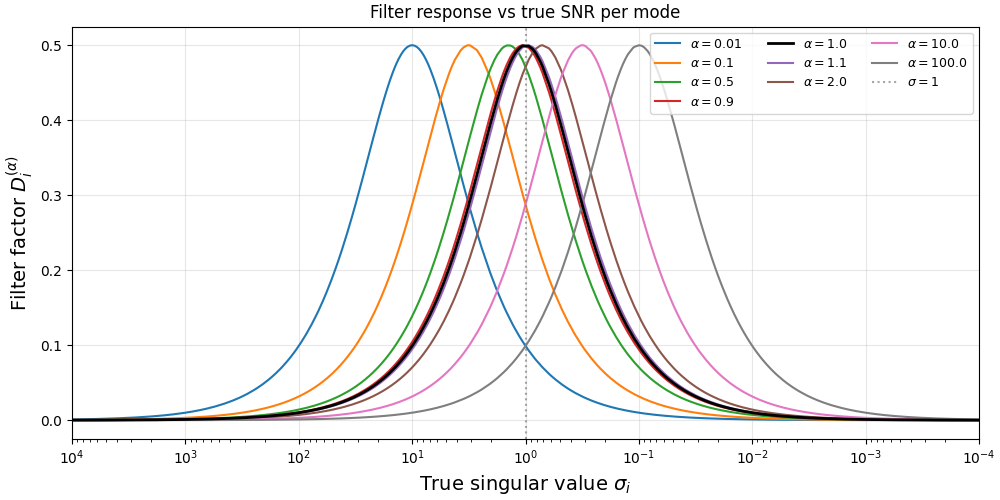

In [12]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

sigma_true = Sigma[:nvec]

for alpha in alphas:
    D = results[alpha]["D_alpha"]
    if np.isclose(alpha, 1.0):
        ax.semilogx(
            sigma_true, D, lw=2, c="k", label=rf"$\alpha={alpha}$", zorder=1000
        )
    else:
        ax.semilogx(
            sigma_true, D, lw=1.5, label=rf"$\alpha={alpha}$"
        )

ax.axvline(1, color="gray", ls=":", alpha=0.7, label=r"$\sigma=1$")
ax.set_xlabel(r"True singular value $\sigma_i$", fontsize=14)
ax.set_ylabel(r"Filter factor $D_i^{(\alpha)}$", fontsize=14)
ax.set_title(
    "Filter response vs true SNR per mode"
)
ax.legend(fontsize=9, ncol=3)
ax.grid(alpha=0.3)
ax.set_xlim(1e-4, 1e4)
ax.invert_xaxis()
plt.show()

### Weighted Mode Contribution

The filter factors change dramatically with $\alpha$, but the modes
where $D_i$ changes most are noise-dominated and carry little signal.
Plotting $|D_i \cdot c_i|$ (filter factor $\times$ projected data)
shows the actual contribution of each mode to the reconstructed map.

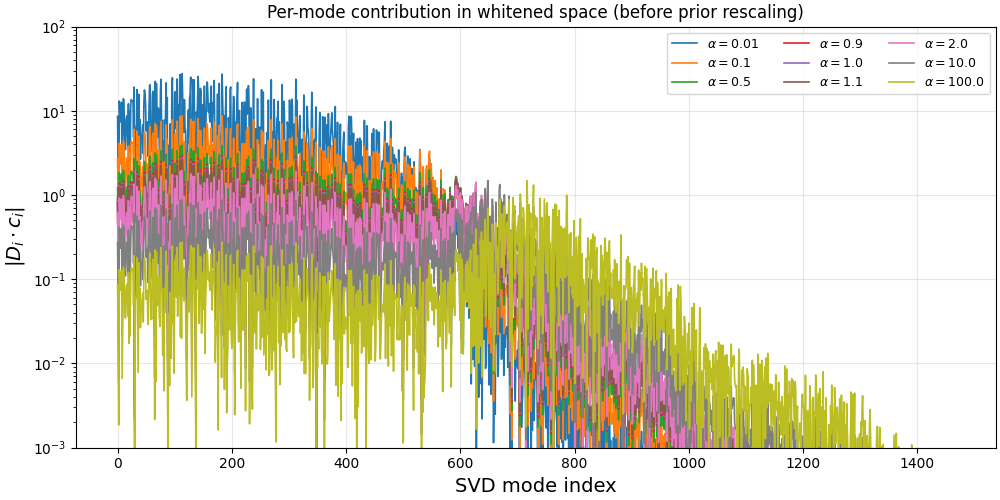

In [13]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

c_abs = np.abs(c[:nvec])

for alpha in alphas:
    D = results[alpha]["D_alpha"]
    contrib = D * c_abs
    ax.semilogy(contrib, lw=1.2, label=rf"$\alpha={alpha}$")

ax.set_xlabel("SVD mode index", fontsize=14)
ax.set_ylabel(r"$|D_i \cdot c_i|$", fontsize=14)
ax.set_title(
    "Per-mode contribution in whitened space "
    "(before prior rescaling)"
)
ax.legend(fontsize=9, ncol=3)
ax.grid(alpha=0.3)
ax.set_ylim(1e-3, 1e2)
plt.show()

## 4. Residual RMS vs $\alpha$

Fractional residual RMS at different $\ell_{\rm max}$ cutoffs
as a function of $\alpha$. The minimum should be near $\alpha = 1$.

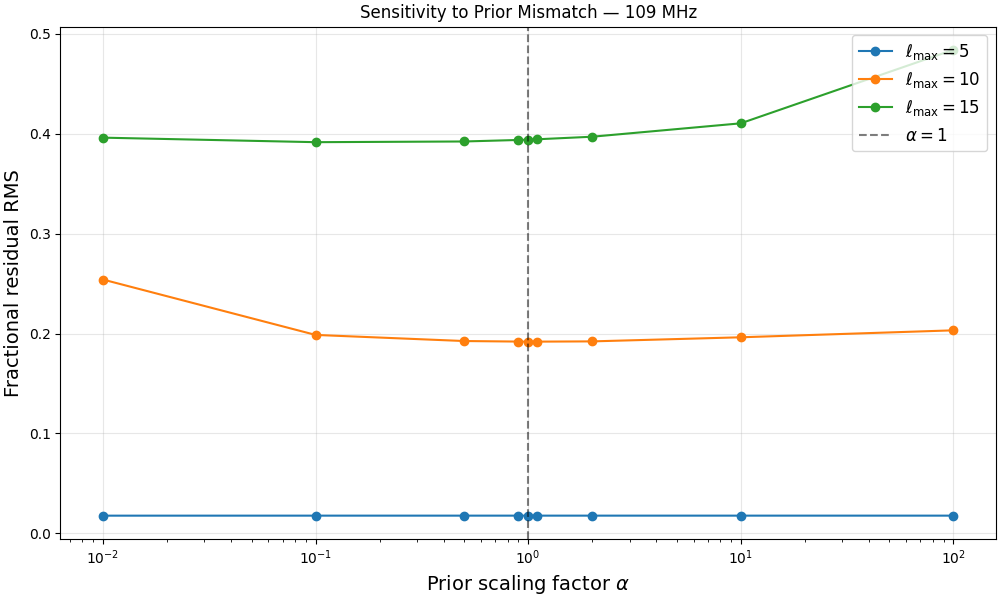

In [14]:
nside = 128
lmax_cuts = [5, 10, 15]

rms_results = {lcut: [] for lcut in lmax_cuts}

for alpha in alphas:
    xr = results[alpha]["x_rec_hp"]
    for lcut in lmax_cuts:
        fl = np.zeros(lmax + 1)
        fl[:lcut + 1] = 1.0
        true_map = hp.alm2map(hp.almxfl(x_true_hp, fl), nside)
        rec_map = hp.alm2map(hp.almxfl(xr, fl), nside)
        frac_res = (true_map - rec_map) / true_map
        rms_results[lcut].append(np.sqrt(np.mean(frac_res**2)))

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for lcut in lmax_cuts:
    ax.semilogx(alphas, rms_results[lcut], "o-", lw=1.5,
                label=rf"$\ell_{{\rm max}} = {lcut}$")
ax.axvline(1.0, color="k", ls="--", alpha=0.5, label=r"$\alpha=1$")
ax.set_xlabel(r"Prior scaling factor $\alpha$", fontsize=14)
ax.set_ylabel("Fractional residual RMS", fontsize=14)
ax.set_title(f"Sensitivity to Prior Mismatch — {freq_mhz:.0f} MHz")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()

## 5. Power Spectrum and Transfer Function

Recovered $C_\ell$ and transfer function $C_\ell^{\rm cross}/C_\ell^{\rm true}$
for selected $\alpha$ values.

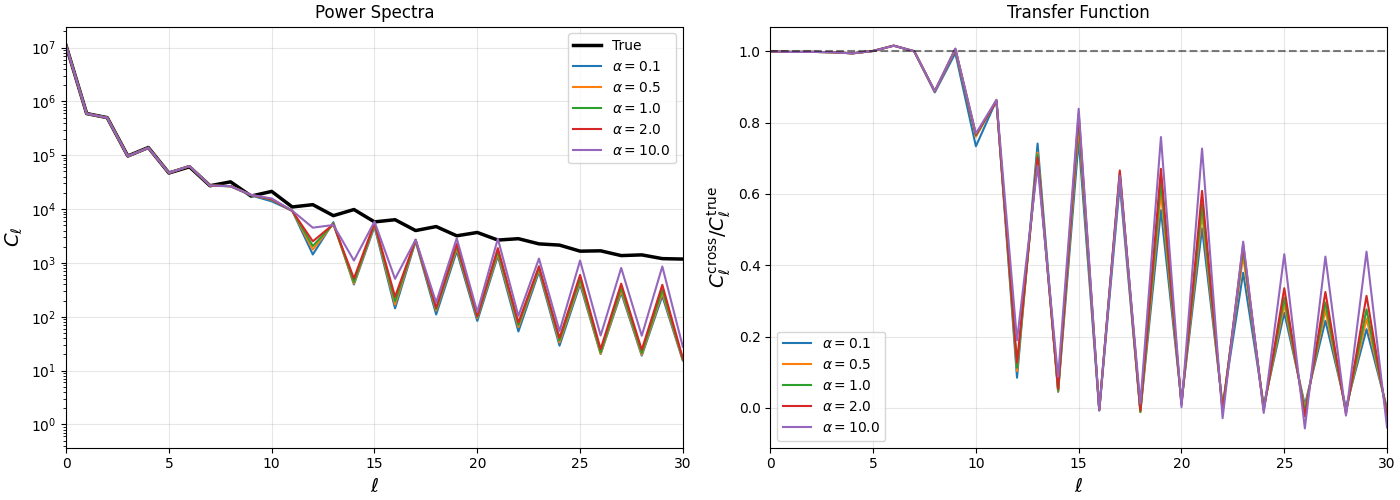

In [15]:
alpha_show = [0.1, 0.5, 1.0, 2.0, 10.0]
cl_true = hp.alm2cl(x_true_hp)
ell = np.arange(len(cl_true))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5), constrained_layout=True,
)

ax1.plot(ell, cl_true, "k-", lw=2.5, label="True")
for alpha in alpha_show:
    cl_rec = hp.alm2cl(results[alpha]["x_rec_hp"])
    ax1.plot(ell, cl_rec, lw=1.5, label=rf"$\alpha={alpha}$")
ax1.set_yscale("log")
ax1.set_xlabel(r"$\ell$", fontsize=14)
ax1.set_ylabel(r"$C_\ell$", fontsize=14)
ax1.set_title("Power Spectra")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 30)

for alpha in alpha_show:
    cl_cross = hp.alm2cl(x_true_hp, results[alpha]["x_rec_hp"])
    tf = np.zeros_like(cl_true)
    valid = cl_true > 0
    tf[valid] = cl_cross[valid] / cl_true[valid]
    ax2.plot(ell, tf, lw=1.5, label=rf"$\alpha={alpha}$")
ax2.axhline(1, color="k", ls="--", alpha=0.5)
ax2.set_xlabel(r"$\ell$", fontsize=14)
ax2.set_ylabel(r"$C_\ell^{\rm cross}/C_\ell^{\rm true}$", fontsize=14)
ax2.set_title("Transfer Function")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 30)

plt.show()

## 6. Map Comparison

True map vs recovered maps for $\alpha = 0.1, 1.0, 10.0$,
low-pass filtered at $\ell \le 10$, in Galactic coordinates.

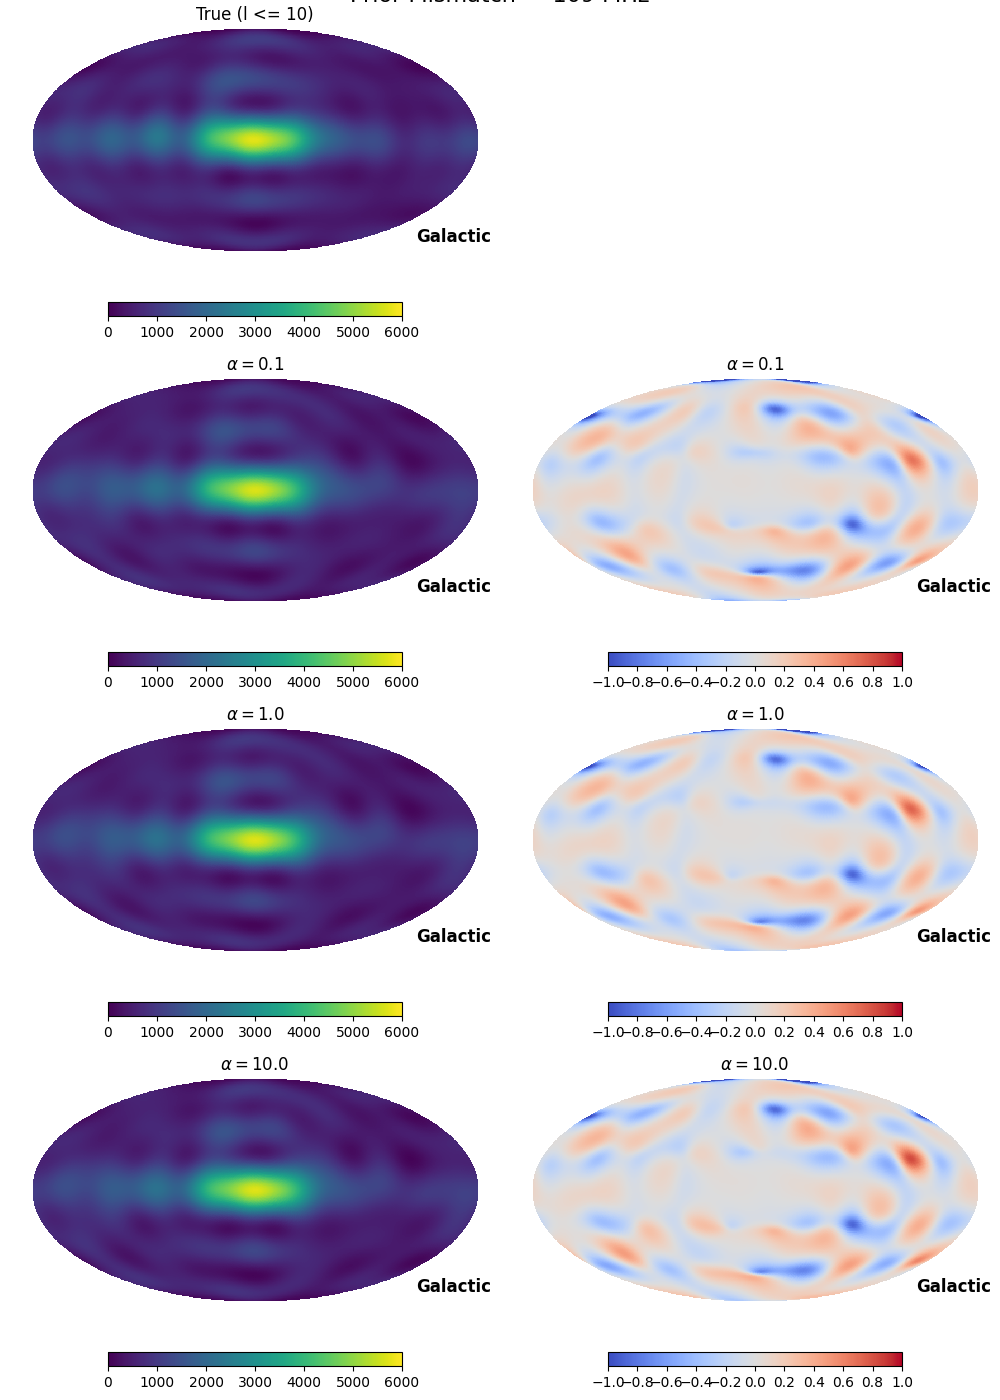

In [20]:
alpha_map = [0.1, 1.0, 10.0]
x_recs = [results[a]["x_rec_hp"] for a in alpha_map]
labels = [rf"$\alpha={a}$" for a in alpha_map]

fig = msplt.plot_comparison_grid(
    x_true_hp, x_recs, labels,
    lmax=lmax, plot_lmax=10, nside=128,
    plot_galactic=True, ratio=True, frac_range=1.0,
    orientation="vertical",
)
fig.suptitle(
    f"Prior Mismatch — {freq_mhz:.0f} MHz",
    fontsize=16, y=1.01,
)
plt.show()

## 7. $a_{\ell m}$ Comparison

True vs recovered spherical harmonic coefficients with
posterior error bars for selected $\alpha$ values.

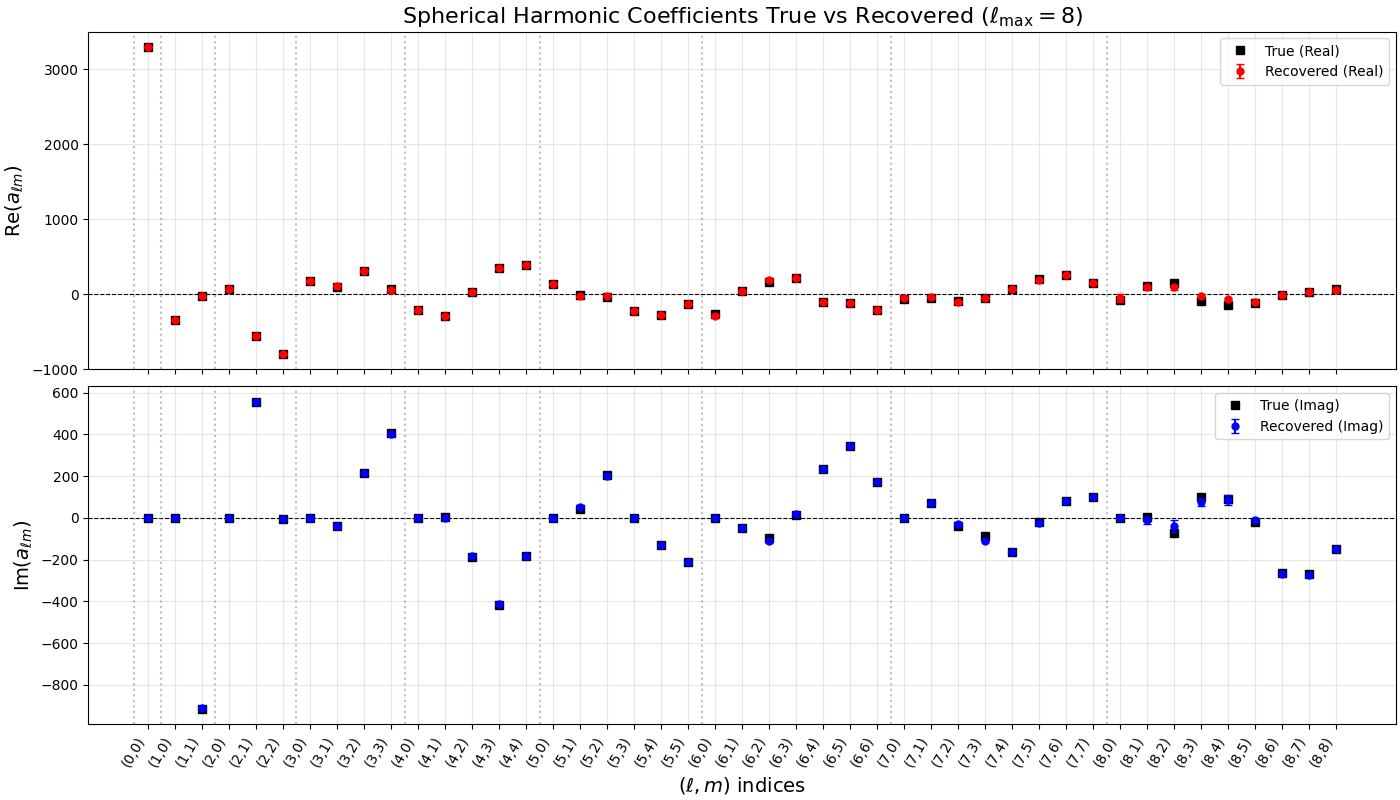

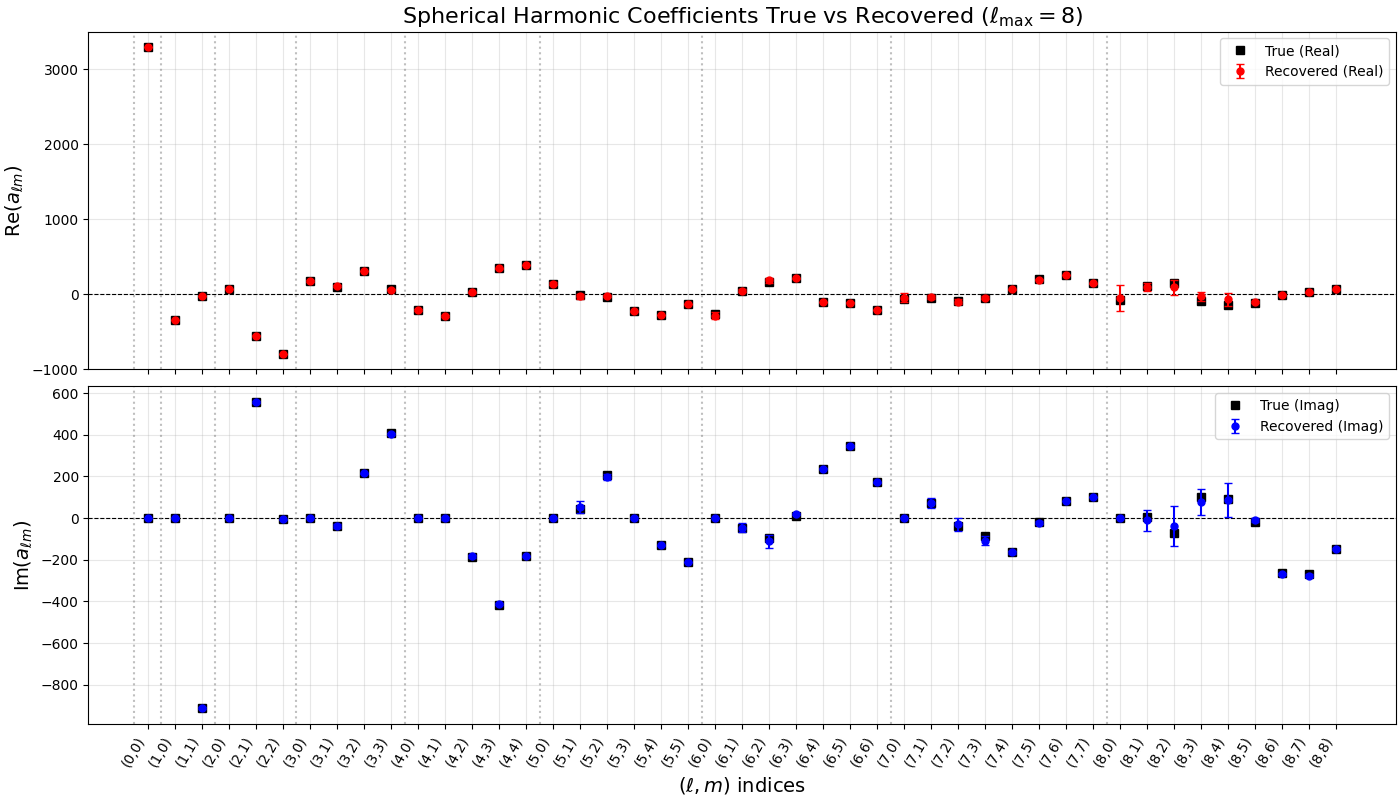

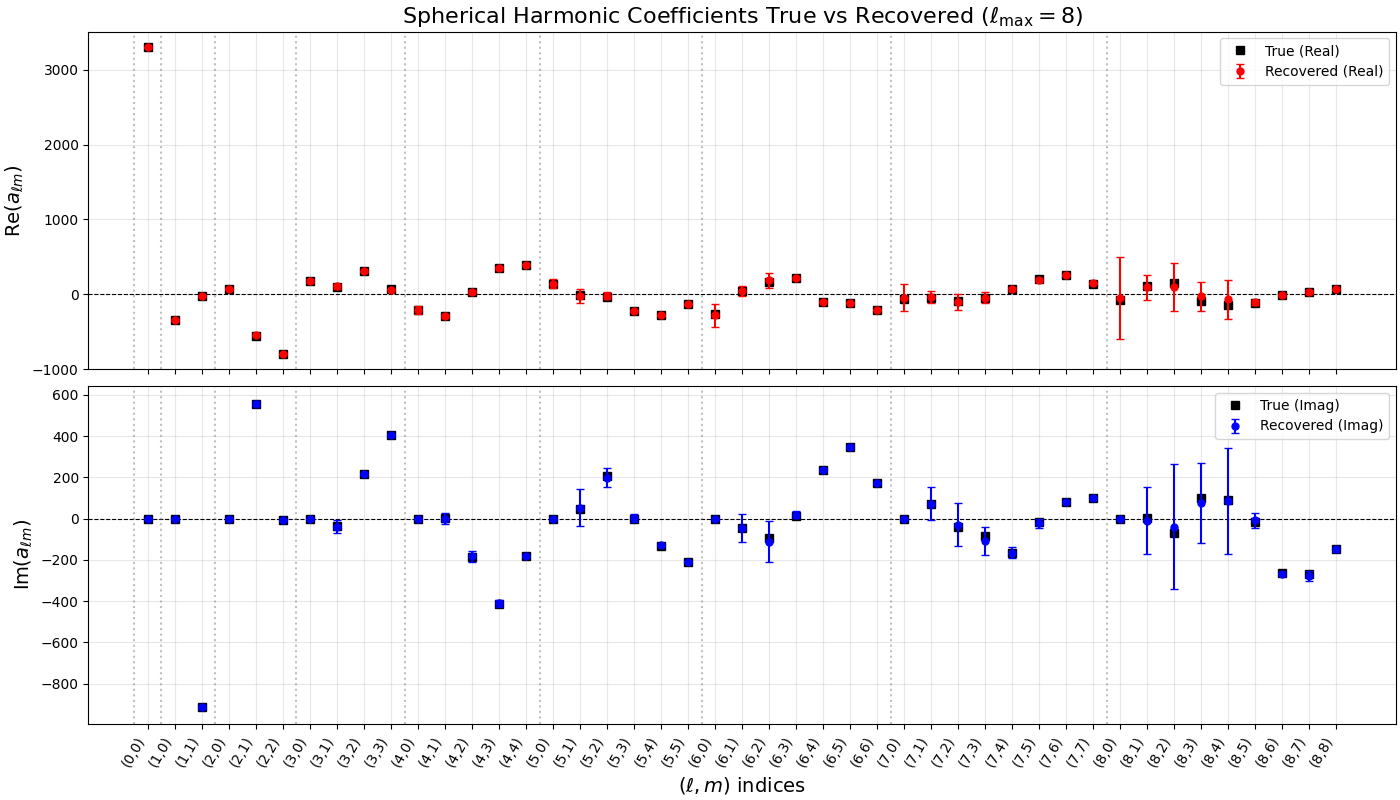

In [10]:
for alpha in [0.1, 1.0, 10.0]:
    res = results[alpha]
    fig = msplt.plot_alm_comparison(
        x_true_hp, res["x_rec_hp"],
        res["std_alm"], lmax, lmax_plot=8,
    )
    fig.suptitle(
        rf"$\alpha = {alpha}$ — {freq_mhz:.0f} MHz",
        fontsize=16, y=1.02,
    )
    plt.show()